In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

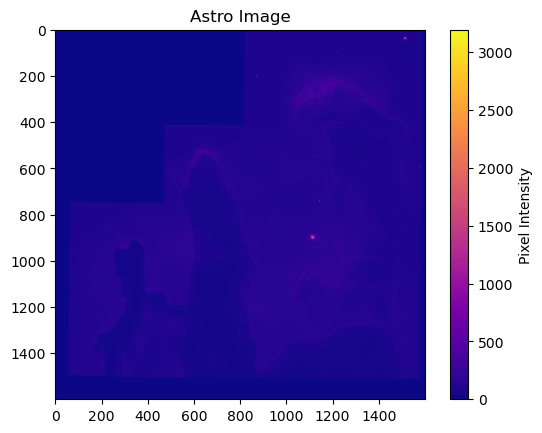

In [2]:
image = np.loadtxt("astro_image.csv", delimiter=" ")
plt.imshow(image,cmap = "plasma")
plt.colorbar(label="Pixel Intensity")
plt.title("Astro Image")
plt.show()

Text(0.5, 1.0, 'middle astro image')

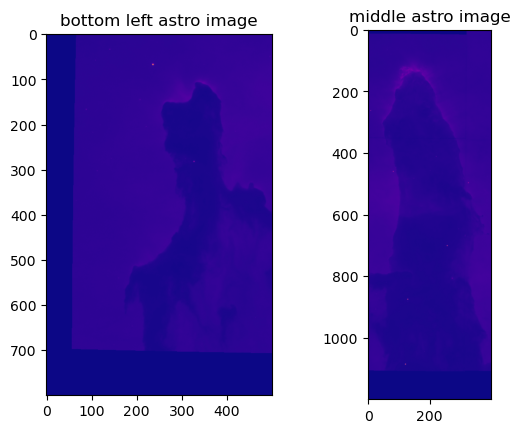

In [3]:
image_bottomleft = image[800:,0:500]
image_middle = image[400:,500:900]
fig,axes = plt.subplots(1,2)
axes[0].imshow(image_bottomleft,cmap = "plasma")
axes[0].set_title("bottom left astro image")
axes[1].imshow(image_middle,cmap = "plasma")
axes[1].set_title("middle astro image")

In [4]:
ramen_ratings = pd.read_csv("ramen-ratings.csv")

In [5]:
#What are the column names in this dataset?
print(ramen_ratings.loc[0])

Review #                         2580
Brand                       New Touch
Variety     T's Restaurant Tantanmen 
Style                             Cup
Country                         Japan
Stars                            3.75
Top Ten                           NaN
Name: 0, dtype: object


In [6]:
#What is the ramen style of the 27th entry?
print(ramen_ratings["Style"][26])

Pack


In [7]:
#How many different ramen brands are there?
brands = ramen_ratings["Brand"].unique()
print(len(brands))

355


In [8]:
#Sort the dataset by brand names.
ramen_ratings = ramen_ratings.sort_values(by='Brand')

In [9]:
#How many ramen brands are made in the USA?
ramen_ratings_USA = ramen_ratings[ramen_ratings["Country"] == "USA"]
print(ramen_ratings_USA.shape)#323 in the usa

(323, 7)


In [10]:
#How many ramen brands in the USA make pack-style ramen?
ramen_ratings_USA_pack = ramen_ratings_USA[ramen_ratings_USA["Style"] == "Pack"]
print(ramen_ratings_USA_pack.shape)#128 pack style in the USA

(128, 7)


In [11]:
from astropy.table import Table
table = Table.read("global_CCl4_MM.dat", format="ascii")

df = table.to_pandas()
df = df[["CCl4ottoyr", "CCl4ottoGLm", "CCl4ottoGLsd"]]

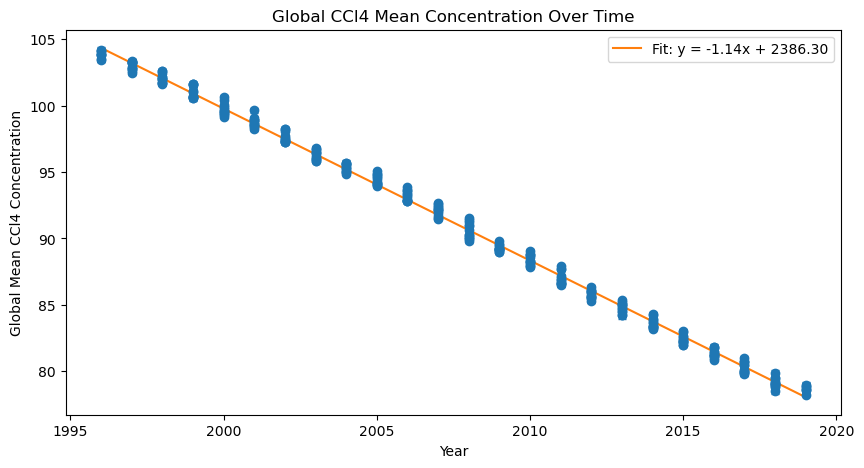

reduced_chi2: 0.17992999424004527


In [13]:
plt.figure(figsize=(10,5))
plt.errorbar(df["CCl4ottoyr"], df["CCl4ottoGLm"], yerr=df["CCl4ottoGLsd"], fmt="o",capsize = 3)
plt.xlabel("Year")
plt.ylabel("Global Mean CCl4 Concentration")
plt.title("Global CCl4 Mean Concentration Over Time")

df_clean = df.dropna(subset=["CCl4ottoyr", "CCl4ottoGLm"])

x = df_clean["CCl4ottoyr"].to_numpy()
y = df_clean["CCl4ottoGLm"].to_numpy()

def line(x, m, b):
    return m*x+b
p0 = [1,1]
popt, pcov = curve_fit(line, x, y, p0=p0)
m_fit, b_fit = popt
y_fit = line(x, m_fit, b_fit)

plt.plot(x, y_fit, label=f"Fit: y = {m_fit:.2f}x + {b_fit:.2f}")
plt.legend()
plt.show()

N = len(y)
reduced_chi2 = np.sum((y-y_fit)**2)/(N-1)
print(f"reduced_chi2: {reduced_chi2}")

#the reduced chi2 being really small is a good thing and thus the model is pretty good
#this means that a linear is pretty close to the real data